<a href="https://colab.research.google.com/github/akshaysinghkiet-prog/case_study_1/blob/main/Customer_Churn_Logistic_Regression_L2_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction using Logistic Regression

A complete real-world ML practical using a Kaggle dataset, EDA, preprocessing, L2 regularization, and classification evaluation.

## Step 1 — Load Dataset

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

# Upload the downloaded CSV file
uploaded = files.upload()

# Get the uploaded filename
filename = next(iter(uploaded))

# Read the CSV file
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2 — Explore the Data

Check dimensions, columns, data types, statistics, missing values, duplicates, and the target distribution.

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInformation:")
df.info()

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   Onlin

In [ ]:
display(df.describe(include="all").T)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0


Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


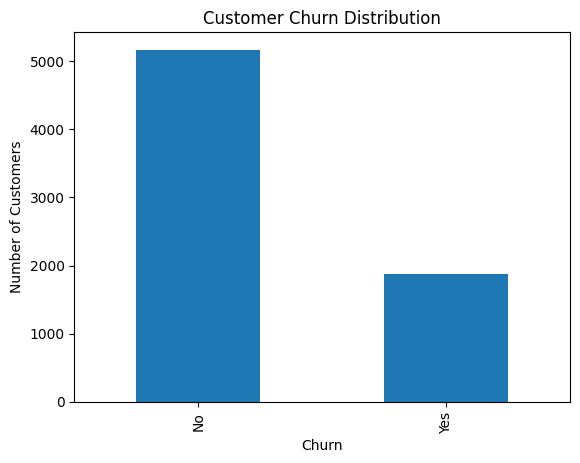

In [ ]:
import matplotlib.pyplot as plt
TARGET = "Churn"

print("Target distribution:")
print(df[TARGET].value_counts())

df[TARGET].value_counts().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

## Step 3 — Handle Missing Values and Duplicates

Remove exact duplicates. Use median for numerical missing values and mode for categorical missing values.

In [ ]:
# Remove duplicates
df = df.drop_duplicates().copy()

# Convert numeric-looking columns stored as text
for col in df.columns:
    if col != TARGET and df[col].dtype == "object":
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().mean() > 0.8:
            df[col] = converted

num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    if col != TARGET:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if col != TARGET and not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:


,0


## Step 4 — Encode Categorical Variables

Convert the binary target to 0/1 and apply one-hot encoding to categorical features.

In [ ]:
# Convert target to 0/1
if df[TARGET].dtype == "object":
    values = df[TARGET].astype(str).str.strip().str.lower()
    mapping = {
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        "churn": 1, "stay": 0,
        "churned": 1, "not churned": 0
    }
    mapped = values.map(mapping)

    if mapped.notna().all():
        df[TARGET] = mapped.astype(int)
    else:
        # General binary fallback
        if df[TARGET].nunique() == 2:
            df[TARGET] = pd.Categorical(df[TARGET]).codes
        else:
            raise ValueError("Target is not binary.")

print(df[TARGET].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
cat_features = df.drop(columns=[TARGET]).select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=cat_features,
    drop_first=True
)

print("Shape after encoding:", df.shape)
display(df.head())

Shape after encoding: (7043, 7073)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


## Step 5 — Separate Features (X) and Target (y)

In [ ]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (7043, 7072)
y shape: (7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


## Step 6 — Train/Test Split and Feature Scaling

Use an 80/20 split with stratification. Fit the scaler only on training data to avoid data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Testing :", X_test_scaled.shape)

Training: (5634, 7072)
Testing : (1409, 7072)


## Step 7 — Logistic Regression with L2 Regularization

Logistic Regression calculates:

$$z = wX+b$$

and converts it into probability using the sigmoid:

$$p = \frac{1}{1+e^{-z}}$$

We use **L2 regularization** to penalize large coefficients.

In scikit-learn:

- `penalty="l2"` selects L2 regularization.
- Smaller `C` = stronger regularization.
- Larger `C` = weaker regularization.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Training completed")
print("Regularization: L2")
print("C:", model.C)

Training completed
Regularization: L2
C: 1.0


In [ ]:
# Class prediction
y_pred = model.predict(X_test_scaled)

# Probability of churn (class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Churn Probability": y_prob
})

display(results.head(10))

,Actual,Predicted,Churn Probability
0,0,0,0.000611
1,0,0,0.461127
2,0,0,0.001870
3,0,0,0.142283
4,0,0,0.000922
5,0,0,0.279233
6,0,0,0.166453
7,0,0,0.003836
8,0,0,0.000106
9,1,0,0.386958


## Step 8 — Evaluate the Model

Use Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, and ROC Curve.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.7842441447835344
Precision: 0.7215189873417721
Recall   : 0.3048128342245989
F1-score : 0.42857142857142855
ROC-AUC  : 0.8307602883050454

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1035
           1       0.72      0.30      0.43       374

    accuracy                           0.78      1409
   macro avg       0.76      0.63      0.65      1409
weighted avg       0.77      0.78      0.75      1409



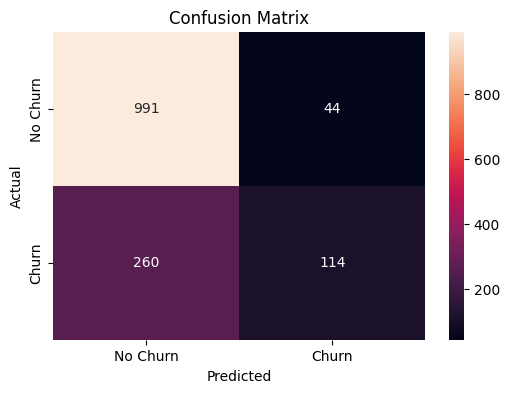

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

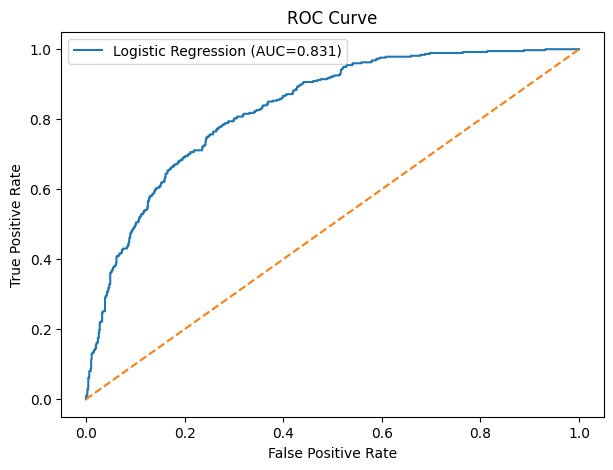

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Compare L2 Regularization Strength

`C` is the inverse of regularization strength. Compare different values.

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]
rows = []

for C in C_values:
    m = LogisticRegression(
        penalty="l2",
        C=C,
        max_iter=1000,
        random_state=42
    )
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    prob = m.predict_proba(X_test_scaled)[:,1]

    rows.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

display(pd.DataFrame(rows))

,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.01,0.773598,0.706767,0.251337,0.370809,0.830047
1,0.10,0.779986,0.719178,0.280749,0.403846,0.830579
2,1.00,0.784244,0.721519,0.304813,0.428571,0.830760
3,10.00,0.793471,0.710660,0.374332,0.490368,0.831179
4,100.00,0.793471,0.715026,0.368984,0.486772,0.831778


## Predict a New Customer

For demonstration, use one customer from the test set. A real new customer must undergo the same encoding and scaling.

In [ ]:
new_customer = X_test.iloc[[0]]
new_customer_scaled = scaler.transform(new_customer)

probability = model.predict_proba(new_customer_scaled)[0,1]
prediction = model.predict(new_customer_scaled)[0]

print("Probability of churn:", round(probability, 3))
print("Prediction:", "Churn" if prediction == 1 else "No Churn")

Probability of churn: 0.001
Prediction: No Churn


# Summary

**Real Dataset → EDA → Missing Values → Encoding → X/y → Train/Test Split → Scaling → Logistic Regression + L2 → Prediction → Evaluation**

### Student Exercises
1. Try `C=0.1` and `C=10`.
2. Compare Precision, Recall and F1.
3. Study the False Negatives in the confusion matrix.
4. Explain why accuracy alone may not be sufficient for churn prediction.